<p style="text-align:center;"><span style="font-size:48px;"><span style="color:#00A36C;"><span style="font-family:cursive;"> Hello everyone! </span> </span>  </span></p>

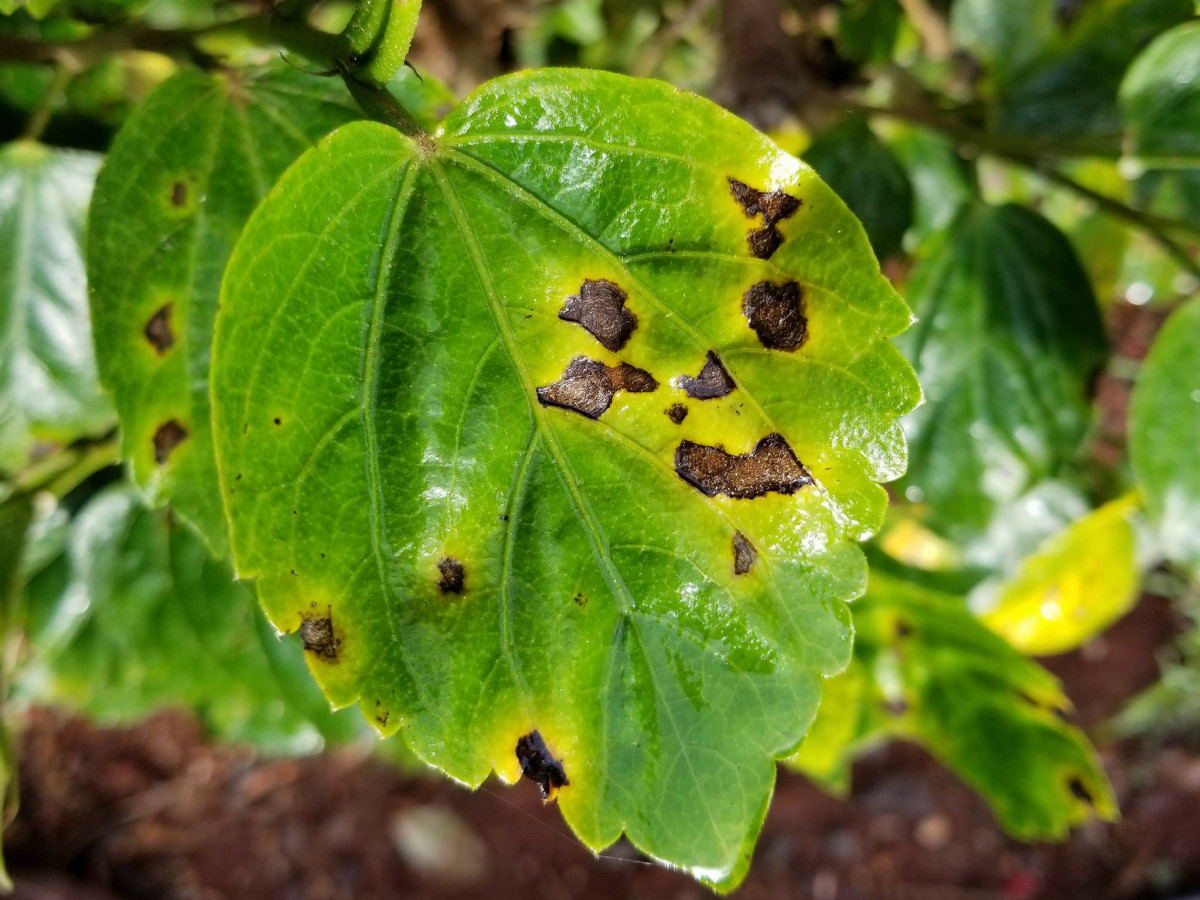

<a id="0"></a>
# <p style="padding:10px;background-color:#2E8B57 ;margin:0;color:#ffffff;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">Table of Contents 💻</p>

<div style = 'border : 3px solid non; background-color:#ECFFDC
              ;font-family:Times New Roman;
              font-size:110%;padding:10px'>

    
    
* **[1. A Brief Explanation](#1)**
   
   - Plant Diseases Detection?
    
   - Why Pytorch and CNN?
    
    
* **[2. Import Libraries ](#2)**
    
   - Libraries that we need
    
  
* **[3. Import Dataset ](#3)**  
    
   - Use Directories 
  
   
* **[4. Data Preprocessing ](#4)**
    
   - Name of Classes and Number of Them
    
   - A Plot of Each Classes
    
   - Comparing the Number of Classes
    
   - ImageFolder, ToTensor
    
   - DataLoader
    
   
* **[5. Device of Process ](#5)**
    
   - GPU/CPU
    
   - Data to Device
    
   - Device DataLoader
    
    
* **[6. Neural Network (CNN) ](#6)**
    
   - Function of Acc
    
   - Classification Base
    
   - ConvBlock
    
   - CNN
    
   - Model
    
   - Model Evaluate / Model Optimizer
    
   - Hyperparameters Function
    
   - Training Model
    
    
 * **[7. Result ](#7)**
    
   - Acc/Loss Plot
    
   - Use Model for Test Dataset
    
   - Final Prediction
    

<a id="1"></a>
# <p style="padding:10px;background-color:#2E8B57 ;margin:0;color:#ffffff;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">A Brief Explanation</p>

<div style = 'border : 3px solid non; background-color:#ECFFDC ; ;padding:10px'>


* **Plant Diseases Detection?**

  - Detecting plant diseases is crucial for several reasons:

    **Agricultural Productivity:** Early identification of diseases can prevent widespread outbreaks, ensuring the health and yield of crops.
    
    **Economic Impact:** Minimizing crop losses due to diseases directly affects the economic stability of farmers and the agriculture industry.
    
    **Food Security:** Protecting crops from diseases is essential to maintain a stable food supply for the growing global population.
    
    **Environmental Protection:** Effective disease management reduces the need for chemical treatments, thus protecting the environment.

    
    

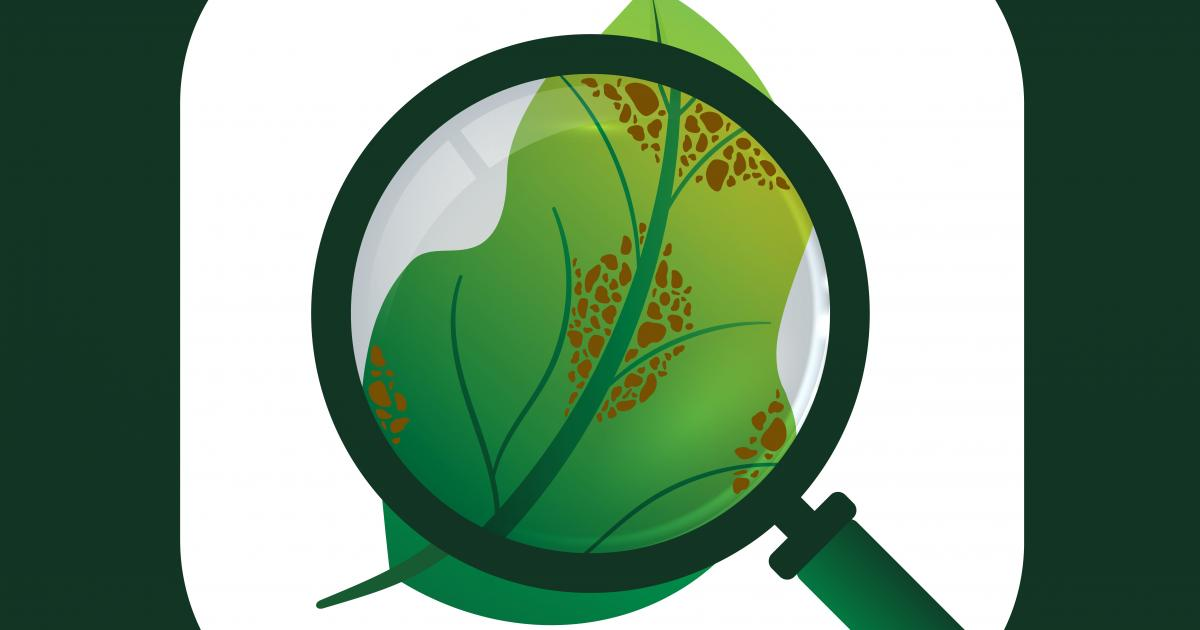

<div style = 'border : 3px solid non; background-color:#ECFFDC ; ;padding:10px'>


* **Why Pytorch and CNN?**

  - PyTorch and Convolutional Neural Networks (CNNs) are particularly well-suited for plant disease detection for several reasons:

    **Ease of Use:** PyTorch provides a flexible platform for deep learning research and development, which is user-friendly for both beginners and experts.
    
    **Dynamic Computation Graphs:** PyTorch allows for dynamic computation graphs that are essential for variable-length inputs and outputs, which is common in image-based tasks.
    
    **Effective Feature Extraction:** CNNs are powerful in extracting hierarchical features from images, which is crucial for identifying patterns indicative of plant diseases.
    
    **Advancements in Deep Learning:** Deep learning, particularly CNNs, has made significant breakthroughs in digital image processing, outperforming traditional methods in accuracy and efficiency.

    
    

* **[Table of Content](#0)**

<a id="2"></a>
# <p style="padding:10px;background-color:#2E8B57 ;margin:0;color:#ffffff;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">Import Libraries</p>

In [ ]:
import warnings
warnings.filterwarnings('ignore') 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from PIL import Image
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import torch.optim as optim
import torch.nn.functional as F
import colorama
from colorama import Fore, Style

* **[Table of Content](#0)**

<a id="3"></a>
# <p style="padding:10px;background-color:#2E8B57 ;margin:0;color:#ffffff;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">Import Dataset</p>

<div style = 'border : 3px solid non; background-color:#ECFFDC ; ;padding:10px'>


* **Use Directories**

  - The main Root of dataset contains 2 folder (New Plant Diseases Dataset (Augmented)) and (Test). In the first one, we can see the directory of **Train** and **Valid** and in the second one, we have our **Test** images.
    
  - The os.listdir() method in Python is used to get the list of all files and directories in the specified directory. If we don’t specify any directory, then a list of files and directories in the current working directory will be returned.

In [ ]:
Root_dir = "/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"
train_dir = Root_dir + "/train"
valid_dir = Root_dir + "/valid"
test_dir = "/kaggle/input/new-plant-diseases-dataset/test"
Diseases_classes = os.listdir(train_dir)

* **[Table of Content](#0)**

<a id="4"></a>
# <p style="padding:10px;background-color:#2E8B57 ;margin:0;color:#ffffff;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">Data Preprocessing</p>

<div style = 'border : 3px solid non; background-color:#ECFFDC ; ;padding:10px'>


* **Name of Classes and Number of Them**

  - How many classes are in the dataset?

In [ ]:
print(Fore.GREEN +str(Diseases_classes))
print("\nTotal number of classes are: ", len(Diseases_classes))

<div style = 'border : 3px solid non; background-color:#ECFFDC ; ;padding:10px'>


* **Name of Classes and Number of Them**

  - How many image are in each classes?
    
  - Also you can see the plot of each classes

In [ ]:
plt.figure(figsize=(60,60), dpi=200)
cnt = 0
plant_names = []
tot_images = 0

for i in Diseases_classes:
    cnt += 1
    plant_names.append(i)
    plt.subplot(7,7,cnt)
    
    image_path = os.listdir(train_dir + "/" + i)
    print(Fore.GREEN)
    print("The Number of Images in " +i+ ":", len(image_path), end= " ")
    tot_images += len(image_path)
    
    img_show = plt.imread(train_dir + "/" + i + "/" + image_path[0])
    
    plt.imshow(img_show)
    plt.xlabel(i,fontsize=30)
    plt.xticks([])
    plt.yticks([])
    
    
print("\nTotal Number of Images in Directory: ", tot_images)

<div style = 'border : 3px solid non; background-color:#ECFFDC ; ;padding:10px'>


* **Comparing the Number of Classes**

  - It's really important to know which classes have the most images and which have the lowest.

* **[Table of Content](#0)**

In [ ]:
plant_names = []
Len = []
for i in Diseases_classes:
    plant_names.append(i)
    imgs_path = os.listdir(train_dir + "/" + i)
    Len.append(len(imgs_path))

Len.sort(reverse=True)

sns.set(style="whitegrid", color_codes=True)
plt.figure(figsize=(20,20),dpi=200)
ax = sns.barplot(x= Len, y= plant_names, palette="Greens")
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()

<div style = 'border : 3px solid non; background-color:#ECFFDC ; ;padding:10px'>


* **ImageFolder/ ToTensor**

  - The ImageFolder class in PyTorch, part of the Torchvision library, is a versatile data loader specifically designed for handling image datasets. It simplifies the process of loading and organizing image data for training machine learning models. Let’s delve into its details:
Purpose: The ImageFolder class is used to load image data from a directory structure where images are organized into subfolders representing different classes or categories. By default, it assumes the following directory structure:

<div style = 'border : 3px solid non; background-color:#ECFFDC ; ;padding:10px'>

    root/
    ├── class_1/
    │   ├── image1.jpg
    │   ├── image2.jpg
    │   └── ...
    ├── class_2/
    │   ├── image3.jpg
    │   ├── image4.jpg
    │   └── ...
    └── ...


In [ ]:
train = ImageFolder(train_dir, transform=transforms.ToTensor())
valid = ImageFolder(valid_dir, transform=transforms.ToTensor()) 

In [ ]:
train

In [ ]:
train[0]


<div style = 'border : 3px solid non; background-color:#ECFFDC ; ;padding:10px'>


The last number (0, 1, 2, ...) shows the number of classes

* **[Table of Content](#0)**

In [ ]:
train[7000]

In [ ]:
train[70000]

In [ ]:
img, label = train[0]
print(img.shape, label)

<div style = 'border : 3px solid non; background-color:#ECFFDC ; ;padding:10px'>


3 is the number of channels (RGB) and 256 x 256 is the width and height of the image

In [ ]:
def show_image(image, label):
    print("Label :" + train.classes[label] + "(" + str(label) + ")")
    plt.imshow(image.permute(1, 2, 0))
    
    
image_list = [0, 3000, 5000, 8000, 12000, 15000, 60000, 70000]
    
chs = 0
for img in image_list:
    chs += 1
    plt.subplot(2,4,chs)
    print(Fore.GREEN)
    plt.tight_layout()
    plt.xlabel(img,fontsize=10)
    plt.title(train[img][1])
    show_image(*train[img])

<div style = 'border : 3px solid non; background-color:#ECFFDC ; ;padding:10px'>


**Permute:** Returns a view of the original tensor input with its dimensions permuted.

**Note:** permute does not copy or allocate memory,

In [ ]:
batch_size = 32

* **[Table of Content](#0)**

<div style = 'border : 3px solid non; background-color:#ECFFDC ; ;padding:10px'>



**DataLoader:**
   - Dataloader is a class for PyTorch data loading utility. It is used to import data from datasets. 
    
   - **Dataloader has two different types of datasets:** map-style datasets and iterable-style datasets. The PyTorch DataLoader class is an important tool to help you prepare, manage, and serve your data to your deep learning networks.
    
   - You can read the main tutorials of this concept in this <a href="https://pytorch.org/tutorials/beginner/basics/data_tutorial.html">**Link**</a>



In [ ]:
# DataLoaders for training and validation
train_dataloader = DataLoader(train, batch_size, shuffle=True, num_workers=2, pin_memory=True)
valid_dataloader = DataLoader(valid, batch_size, num_workers=2, pin_memory=True)

* **[Table of Content](#0)**

<a id="5"></a>
# <p style="padding:10px;background-color:#2E8B57 ;margin:0;color:#ffffff;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">Device of Process</p>

<div style = 'border : 3px solid non; background-color:#ECFFDC ; ;padding:10px'>



**GPU/CPU:** 
   - When designing your deep learning architecture, your decision to include GPUs relies on several factors:

   - Memory bandwidth—including GPUs can provide the bandwidth needed to accommodate large datasets. 
    
   - Dataset size GPUs in parallel can scale more easily than CPUs, enabling you to process massive datasets faster.
    
   - Optimization a downside of GPUs is that optimization of long-running individual tasks is sometimes more difficult than with CPUs.



In [ ]:
# for moving data into GPU (if available)
def get_default_device():
    """Pick GPU if available, else CPU"""
    if torch.cuda.is_available:
        return torch.device("cuda")
    else:
        return torch.device("cpu")

<div style = 'border : 3px solid non; background-color:#ECFFDC ; ;padding:10px'>


   - You can read more about this in <a href="https://pytorch.org/blog/pytorch-0_4_0-migration-guide/#writing-device-agnostic-code">**HERE**</a>


<div style = 'border : 3px solid non; background-color:#ECFFDC ; ;padding:10px'>


**Data to Device:** 


   - In PyTorch, it’s crucial to use .to(device) when you explicitly want to move tensors (data) or entire models (including layers and parameters) to a specific device for computation. **Here’s why:**

   - **Consistent Device Placement:**
When working with GPUs (Graphics Processing Units), you need to ensure that both the model and the data reside on the same device (either CPU or GPU).
If the data is on the CPU and the model is on the GPU (or vice versa), you’ll encounter a runtime error.
To avoid this, use .to(device) to transfer both the data and the model to the same device.
    
   - **Avoiding Mixed Device Operations:**
If an operation involves one tensor on the GPU and another on the CPU, PyTorch will raise a Runtime Error.
For example, attempting to perform operations between tensors on different devices will result in an error like: “Expected object of device type cuda but got device type cpu.”
    
   - **Setting the Device:**
You can set a variable device to 'cuda' if a GPU is available, otherwise set it to 'cpu'.
Then, move both the model and the data to the specified device:

In [ ]:
# for moving data to device (CPU or GPU)
def to_device(data, device):
    """Move tensor(s) to chosen device"""
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

<div style = 'border : 3px solid non; background-color:#ECFFDC ; ;padding:10px'>


**Device DataLoader:** 


   - There is a great tutorial for this section that you can see <a href="https://pytorch.org/docs/stable/data.html">**HERE**</a>.
    
   - In the cell below, we can combine out dataloader and the main device.

<div style = 'border : 3px solid non; background-color:#ECFFDC ; ;padding:10px'>



   - To understand what yield does, you must understand what
<a href="https://docs.python.org/3/glossary.html#term-generator">**generators**</a> are. And before you can understand generators, you must understand <a href="https://docs.python.org/3/glossary.html#term-iterable">**iterables**</a>.
    
    
   - <a href="https://www.geeksforgeeks.org/python-yield-keyword/">**yield**</a>  is a keyword that is used like return, except the function will return a generator.

In [ ]:
# for loading in the device (GPU if available else CPU)
class DeviceDataLoader():
    """Wrap a dataloader to move data to a device"""
    def __init__(self, dataloader, device):
        self.dataloader = dataloader
        self.device = device
        
    def __iter__(self):
        """Yield a batch of data after moving it to device"""
        for b in self.dataloader:
            yield to_device(b, self.device)
        
    def __len__(self):
        """Number of batches"""
        return len(self.dataloader)

In [ ]:
device = get_default_device()
device

<div style = 'border : 3px solid non; background-color:#ECFFDC ; ;padding:10px'>



   - CUDA is a programming model and computing toolkit developed by NVIDIA. It enables you to perform compute-intensive operations faster by parallelizing tasks across GPUs. CUDA is the dominant API used for deep learning although other options are available, such as OpenCL. PyTorch provides support for CUDA in the torch.cuda library.

In [ ]:
# Moving data into GPU, WrappedDataLoader
train_dataloader = DeviceDataLoader(train_dataloader, device)
valid_dataloader = DeviceDataLoader(valid_dataloader, device)

* **[Table of Content](#0)**

<a id="6"></a>
# <p style="padding:10px;background-color:#2E8B57 ;margin:0;color:#ffffff;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">Neural Network (CNN)</p>

<div style = 'border : 3px solid non; background-color:#ECFFDC ; ;padding:10px'>


**Function of Acc:** 


   - We can compare the outputs of model with the true labels.

In [ ]:
# for calculating the accuracy
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))


<div style = 'border : 3px solid non; background-color:#ECFFDC ; ;padding:10px'>


**Classification Base:** 


   - Let's create a step by step classification base module:
    
   - **First, Training_step:** the images and labels take values from batch. The output of model is a type of images and the loss is calculate from **F** cross entropy function (out, labels). It seems that the prediction is compared with the actual values in labels.
    
   - **Second, validation step:** is just like the above one. But it has another attribute call acc.
    
   - **Third, validation_epoch_end:** calculate the losses and acces of each batchs and epochs.
    
   - **Fourth, epoch_end:** That shows the final results of everything.
    
    

In [ ]:
class ImageClassificationBase(nn.Module):
    
    def training_step(self, batch):
        images, labels = batch 
        out = self(images)                  # Generate predictions
        loss = F.cross_entropy(out, labels) # Calculate loss
        return loss
    
    def validation_step(self, batch):
        images, labels = batch 
        out = self(images)                    # Generate predictions
        loss = F.cross_entropy(out, labels)   # Calculate loss
        acc = accuracy(out, labels)           # Calculate accuracy
        return {'val_loss': loss.detach(), 'val_acc': acc}
        
    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()   # Combine losses
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()      # Combine accuracies
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}
    
    def epoch_end(self, epoch, result):
        print("Epoch [{}], train_loss: {:.4f}, val_loss: {:.4f}, val_acc: {:.4f}".format(
            epoch, result['train_loss'], result['val_loss'], result['val_acc']))


<div style = 'border : 3px solid non; background-color:#ECFFDC ; ;padding:10px'>


**ConvBlock:** 


   - Number of inputs, outputs, kernel size and padding are here.
    
   - Also we have Batchnomalization
    
   - You see other tutorials and ways in this <a href="https://www.geeksforgeeks.org/python-yield-keyword/">**lecture**</a>
    
   - For Maxpooling you can see this <a href="https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html">**Link**</a> 
    
    

In [ ]:
# convolution block with BatchNormalization
def ConvBlock(in_channels, out_channels, pool=False):
    layers = [nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
             nn.BatchNorm2d(out_channels),
             nn.ReLU(inplace=True)]
    if pool:
        layers.append(nn.MaxPool2d(4))
    return nn.Sequential(*layers)


<div style = 'border : 3px solid non; background-color:#ECFFDC ; ;padding:10px'>


**CNN:** 


   - And the CNN part
    
   - We can use the class of **ImageClassificationBase** for taking methods like calculating the loss and acc of epochs. And after that, we can set our layers. We can use more layers but in this case, the size of images don't allow to do that **Going to be zero**. In the second part, we have to connect layers to each other. The output of layer number **N**, is the input of layer number **N+1**. And so on.

* **[Table of Content](#0)**

In [ ]:
# resnet architecture 
class CNN_NeuralNet(ImageClassificationBase):
    def __init__(self, in_channels, num_diseases):
        super().__init__()
        
        self.conv1 = ConvBlock(in_channels, 64)
        self.conv2 = ConvBlock(64, 128, pool=True) 
        self.res1 = nn.Sequential(ConvBlock(128, 128), ConvBlock(128, 128))
        
        self.conv3 = ConvBlock(128, 256, pool=True) 
        self.conv4 = ConvBlock(256, 512, pool=True)
        #self.conv5 = ConvBlock(256, 256, pool=True)
        #self.conv6 = ConvBlock(256, 512, pool=True)
        #self.conv7 = ConvBlock(512, 512, pool=True)
        
        self.res2 = nn.Sequential(ConvBlock(512, 512), ConvBlock(512, 512))
        self.classifier = nn.Sequential(nn.MaxPool2d(4),
                                       nn.Flatten(),
                                       nn.Linear(512, num_diseases))
        
    def forward(self, x): # x is the loaded batch
        out = self.conv1(x)
        out = self.conv2(out)
        out = self.res1(out) + out
        out = self.conv3(out)
        out = self.conv4(out)
        #out = self.conv5(out)
        #out = self.conv6(out)
        #out = self.conv7(out)
        out = self.res2(out) + out
        out = self.classifier(out)
        return out        


<div style = 'border : 3px solid non; background-color:#ECFFDC ; ;padding:10px'>


**Model:** 


   - Now it's time to connet the model to_device for using GPU

In [ ]:
# defining the model and moving it to the GPU
# 3 is number of channels RGB, len(train.classes()) is number of diseases.
model = to_device(CNN_NeuralNet(3, len(train.classes)), device) 
model


<div style = 'border : 3px solid non; background-color:#ECFFDC ; ;padding:10px'>


**Model Evaluate / Model Optimizer:** 


   - We can define evaluate between model output and validation labels.
    
   - There is no reason to track gradients when updating the weights. The torch.no_grad() tells PyTorch to not calculate the gradients, and the program explicitly uses it here (as with most neural networks) in order to not update the gradients when it is updating the weights as that would affect the back propagation. It’s commonly used during weight updates to avoid interfering with backpropagation.
    
   - For getting learning rate from the model, we can use 'lr' as learning rate in optimizer.param_groups.

In [ ]:
# for training
@torch.no_grad()
def evaluate(model, val_loader):
    model.eval()
    outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)

In [ ]:
def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group['lr']


<div style = 'border : 3px solid non; background-color:#ECFFDC ; ;padding:10px'>


**Hyperparameters Function:** 


   - Now it's time to create a function that get **epochs, learning rate, train and validation loader and optim function.**.
    
   - Clear GPU memory after PyTorch model training without restarting kernel with **torch.cuda.empty_cache()**   
    

In [ ]:
def fit_OneCycle(epochs, max_lr, model, train_loader, val_loader, weight_decay=0,
                grad_clip=None, opt_func=torch.optim.SGD):
    torch.cuda.empty_cache()
    history = []  #For collecting the results
    
    optimizer = opt_func(model.parameters(), max_lr, weight_decay=weight_decay)
    # scheduler for one cycle learniing rate
    #Sets the learning rate of each parameter group according to the 1cycle learning rate policy. 
    #The 1cycle policy anneals the learning rate from an initial learning rate to some 
    #maximum learning rate and then from that maximum learning rate to some minimum learning rate
    #much lower than the initial learning rate. 
    sched = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr,
                                                epochs=epochs, steps_per_epoch=len(train_loader))
    
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_losses = []
        lrs = []
        for batch in train_loader:
            loss = model.training_step(batch)
            train_losses.append(loss)
            loss.backward()
            
            # gradient clipping
            #Clip the gradients of an iterable of parameters at specified value.
            #All from pytorch documantation.
            if grad_clip: 
                nn.utils.clip_grad_value_(model.parameters(), grad_clip)
                
            optimizer.step()
            optimizer.zero_grad()
            
            # recording and updating learning rates
            lrs.append(get_lr(optimizer))
            sched.step()
             # validation
        
        result = evaluate(model, val_loader)
        result['train_loss'] = torch.stack(train_losses).mean().item()
        result['lrs'] = lrs
        model.epoch_end(epoch, result)
        history.append(result)
        
    return history
    


<div style = 'border : 3px solid non; background-color:#ECFFDC ; ;padding:10px'>


**Training Model:** 


   - Evaluate function added to history of model.
    
   - Then we can define our hyperparameters like number of epochs, learning rate and ... .
    
   - Now we can update history with fit_OneCycle function (Adding two function together).
    Attention to history = [] in the second function. Now we have model evaluation.
    

In [ ]:
%%time
history = [evaluate(model, valid_dataloader)]
history

In [ ]:
num_epoch = 5
lr_rate = 0.01
grad_clip = 0.15
weight_decay = 1e-4
optims = torch.optim.Adam

In [ ]:
%%time
history += fit_OneCycle(num_epoch, lr_rate, model, train_dataloader, valid_dataloader, 
                             grad_clip=grad_clip, 
                             weight_decay=weight_decay, 
                             opt_func=optims)

* **[Table of Content](#0)**

<a id="7"></a>
# <p style="padding:10px;background-color:#2E8B57 ;margin:0;color:#ffffff;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">Result</p>


<div style = 'border : 3px solid non; background-color:#ECFFDC ; ;padding:10px'>


**Acc/Loss Plot:** 


   - If you call **history** you can see the parameters in it. We want to plot **val_acc, val_loss and train_loss**. 
    

In [ ]:
val_acc = []
val_loss = []
train_loss = []

for i in history:
    val_acc.append(i['val_acc'])
    val_loss.append(i['val_loss'])
    train_loss.append(i.get('train_loss'))

In [ ]:
epoch_count = range(1,7)
plt.figure(figsize=(10,5), dpi=200)
plt.plot(epoch_count, train_loss, 'r--', color= 'orangered')
plt.plot(epoch_count, val_loss, '--bo',color= 'green', linewidth = '2.5', label='line with marker')
plt.legend(['Training Loss', 'Val Loss'])
plt.title('Number of epochs & Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(np.arange(1,7,1))
plt.show();

In [ ]:
epoch_count = range(1,7)
plt.figure(figsize=(10,5), dpi=200)
plt.plot(epoch_count, val_acc, '--bo',color= 'green', linewidth = '2.5', label='line with marker')
plt.legend(['Val Acc'])
plt.title('Number of epochs & Acc')
plt.xlabel('Epoch')
plt.ylabel('Acc')
plt.xticks(np.arange(1,7,1))
plt.show();


<div style = 'border : 3px solid non; background-color:#ECFFDC ; ;padding:10px'>


**Use Model for Test Dataset:** 


   - Now it's time to test the model on the **test_dir**.

In [ ]:
test = ImageFolder(test_dir, transform=transforms.ToTensor())
test_images = sorted(os.listdir(test_dir + '/test'))
print(Fore.GREEN)
print(test_images)
print(len(test_images))

In [ ]:
def predict_image(img, model):
    """Converts image to array and return the predicted class
        with highest probability"""
    # Convert to a batch of 1
    xb = to_device(img.unsqueeze(0), device)
    # Get predictions from model
    yb = model(xb)
    # Pick index with highest probability
    _, preds  = torch.max(yb, dim=1)
    # Retrieve the class label

    return train.classes[preds[0].item()]

<div style = 'border : 3px solid non; background-color:#ECFFDC ; ;padding:10px'>


**Final Prediction:** 


   - Let's see how the model works.

In [ ]:
# predicting first image
img, label = test[1]
plt.imshow(img.permute(1, 2, 0))
print(Fore.GREEN)
print('Label:', test_images[1], ', Predicted:', predict_image(img, model))

In [ ]:
# predicting first image
img, label = test[5]
plt.imshow(img.permute(1, 2, 0))
print(Fore.GREEN)
print('Label:', test_images[5], ', Predicted:', predict_image(img, model))

In [ ]:
# predicting first image
img, label = test[9]
plt.imshow(img.permute(1, 2, 0))
print(Fore.GREEN)
print('Label:', test_images[9], ', Predicted:', predict_image(img, model))

In [ ]:
# predicting first image
img, label = test[16]
plt.imshow(img.permute(1, 2, 0))
print(Fore.GREEN)
print('Label:', test_images[16], ', Predicted:', predict_image(img, model))

In [ ]:
# predicting first image
img, label = test[26]
plt.imshow(img.permute(1, 2, 0))
print(Fore.GREEN)
print('Label:', test_images[26], ', Predicted:', predict_image(img, model))

In [ ]:
# getting all predictions (actual label vs predicted)
for i, (img, label) in enumerate(test):
    print(Fore.GREEN)
    print('Label:', test_images[i], ', Predicted:', predict_image(img, model))

<div style = 'border : 3px solid non; background-color:#ECFFDC ; ;padding:10px'> 


   - Everything is good and the model predict well the test dataset.
    
   - **Happy Learning Guys**

# <p style="padding:10px;background-color:#2E8B57 ;margin:0;color:#ffffff;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">Warm Wishes</p>